# Problem Set 3 - Markov Chains (Solutions)

David Evans  
2026-04-29

# A Two-State Labor Market

## Problem 1: Unemployment as a Markov Chain

Consider a worker who is either **employed** (state 1) or **unemployed**
(state 2). Each period:

-   An unemployed worker finds a job with probability $p$.
-   An employed worker is fired with probability $f$.

**(a)** Construct the $2 \times 2$ transition matrix $P$ for this
worker. Use calibrated values $p = 0.4$ (monthly job-finding rate) and
$f = 0.03$ (monthly separation rate). Verify that each row of $P$ sums
to 1.

In [25]:
using Plots,LinearAlgebra,Random,Distributions
p = 0.4
f = 0.03

P = [1-f   f;
     p     1-p]

2×2 Matrix{Float64}:
 0.97  0.03
 0.4   0.6

In [26]:
P

2×2 Matrix{Float64}:
 0.97  0.03
 0.4   0.6

In [27]:
sum(P, dims=2)

2×1 Matrix{Float64}:
 1.0
 1.0

Row 1 is the conditional distribution given currently *employed*: with
probability $1-f$ the worker stays employed, with probability $f$ they
are fired. Row 2 is the conditional distribution given currently
*unemployed*: with probability $p$ they find a job, with probability
$1-p$ they remain unemployed. Each row sums to 1, as required.

**(b)** Write code to simulate $N = 100{,}000$ workers for $T = 100$
periods, with everyone starting employed. At each date $t$, record the
fraction of workers who are unemployed. Plot this unemployment rate over
time.

We reuse `simulateMarkov` (and its helper `drawDiscrete`) from lecture —
we’ll also need them in Problem 6.

In [28]:
function drawDiscrete(pvec, X̄)
    dist = Categorical(pvec)
    s = rand(dist)
    return s, X̄[s]
end

function simulateMarkov(P, X̄, T; s₁ = 1)
    X = zeros(T)
    s = zeros(Int, T)
    s[1] = s₁
    X[1] = X̄[s₁]
    for t in 2:T
        s[t], X[t] = drawDiscrete(P[s[t-1], :], X̄)
    end
    return s, X
end

simulateMarkov (generic function with 1 method)

Setting $\bar X = (0, 1)$ turns the simulated path into an
**unemployment indicator** (0 if employed, 1 if unemployed). Averaging
these across workers gives the unemployment rate.

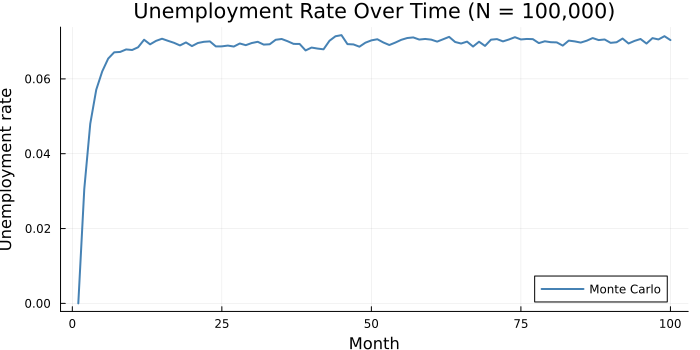

In [29]:
Random.seed!(42)

N = 100_000
T = 100
X̄_ind = [0.0, 1.0]             # 0 = employed, 1 = unemployed

u_rate_mc = zeros(T)
for i in 1:N
    _, X = simulateMarkov(P, X̄_ind, T; s₁ = 1)
    u_rate_mc .+= X
end
u_rate_mc ./= N

plot(1:T, u_rate_mc, linewidth=2, color=:steelblue, label="Monte Carlo",
     title="Unemployment Rate Over Time (N = 100,000)",
     xlabel="Month", ylabel="Unemployment rate", size=(700, 350))

**(c)** What happens to the unemployment rate over time? Does it settle
down?

The unemployment rate rises quickly from zero over roughly the first
10–15 months and then levels off, fluctuating around a long-run value
near 7%. Once the distribution of workers over employment states stops
changing (in expectation), the aggregate unemployment rate stops
trending. This long-run value is the **steady state** we will
characterize in Problems 2–4.

## Problem 2: The Aggregate Law of Motion

Let $u_t$ be the fraction of the labor force that is unemployed at date
$t$ and $e_t$ the fraction employed, so $u_t + e_t = 1$. For a very
large labor force, the aggregate law of motion is:

$$
u_{t+1} = u_t + f e_t - p u_t, \qquad
e_{t+1} = e_t - f e_t + p u_t.
$$

**(a)** Construct the matrix $A$.

Stacking the aggregate vector in the same ordering as $P$, i.e. $(e_t, u_t)$, we can rewrite the law of motion as a linear map:

\begin{align*}
e_{t+1} &= (1-f) e_t + p u_t, \\
u_{t+1} &= f e_t + (1-p) u_t,
\end{align*}

so

$$
A = \begin{pmatrix} 1-f & p \\ f & 1-p \end{pmatrix} = P^\top.
$$

Each row of $P$ is a conditional distribution over *next-period* states
given the current state. Aggregating across workers reverses the sense
of “from” and “to,” which is exactly transposition: $A = P^\top$.

In [30]:
A = [1-f   p;
     f     1-p]
A

2×2 Matrix{Float64}:
 0.97  0.4
 0.03  0.6

Verify $A = P^\top$:

In [31]:
A == P'

true

**(b)** Using $A$, simulate the unemployment and employment rates
forward for $T = 100$ periods starting from $u_0 = 0$, $e_0 = 1$, and
plot on the same axes as the Monte Carlo path.

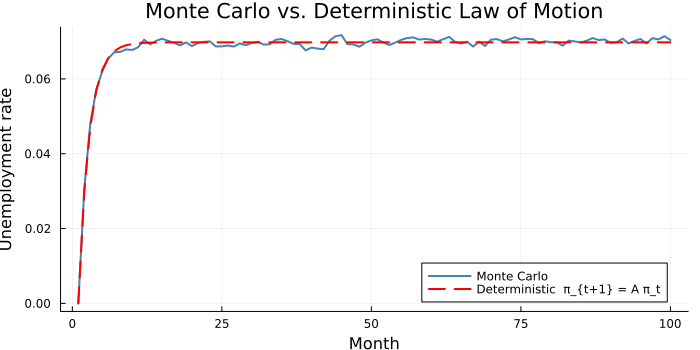

In [32]:
π = [1.0, 0.0]               # (e_0, u_0)
u_rate_det = zeros(T)
u_rate_det[1] = π[2]
for t in 2:T
    π = A * π
    u_rate_det[t] = π[2]
end

plot(1:T, u_rate_mc, linewidth=2, color=:steelblue, label="Monte Carlo",
     title="Monte Carlo vs. Deterministic Law of Motion",
     xlabel="Month", ylabel="Unemployment rate", size=(700, 350))
plot!(1:T, u_rate_det, linewidth=2, color=:red, linestyle=:dash,
      label="Deterministic  π_{t+1} = A π_t")

**(c)** How close is the Monte Carlo path to the deterministic path?

The two paths lie almost exactly on top of each other. For any
individual worker, next period’s state is random. But with
$N = 100{,}000$ independent workers, the **law of large numbers** means
that the fraction of workers in each state is essentially the population
probability of being in that state. The aggregate law of motion is
exactly the dynamics of those population probabilities, so for large $N$
the Monte Carlo unemployment rate converges to the deterministic one.

## Problem 3: Steady States

**(a)** Compute $\pi^*$ by iterating $\pi_t = A^t \pi_0$.

In [33]:
π₀ = [1.0, 0.0]                          # (e_0, u_0)
π_ss = A^500 * π₀
println("Steady state from iteration:")
println("  e* = $(round(π_ss[1], digits=5))")
println("  u* = $(round(π_ss[2], digits=5))")

Steady state from iteration:
  e* = 0.93023
  u* = 0.06977


**(b)** What does $P^t$ converge to?

In [34]:
P_inf = P^500
round.(P_inf, digits=5)

2×2 Matrix{Float64}:
 0.93023  0.06977
 0.93023  0.06977

Each row of $P^{500}$ is the same and equals the long-run distribution
over $(e, u)$. Regardless of the current state, after enough periods the
conditional distribution over future states is the same and that
distribution is the steady state. Reading off the first row we get
$(e^*, u^*) \approx (0.930, 0.070)$, matching Part (a).

**(c)** Show analytically that $u^* = f/(p+f)$, $e^* = p/(p+f)$.

In steady state, $u^* = (1-p) u^* + f e^*$ and $u^* + e^* = 1$.
Substituting $e^* = 1 - u^*$:

$$
u^* = (1-p) u^* + f (1 - u^*)
\;\;\Longrightarrow\;\;
u^* (p + f) = f
\;\;\Longrightarrow\;\;
u^* = \frac{f}{p + f}.
$$

And therefore $e^* = 1 - u^* = p/(p+f)$.

In [35]:
u_star = f / (p + f)
e_star = p / (p + f)

println("Closed-form steady state:")
println("  u* = $(round(u_star, digits=5))")
println("  e* = $(round(e_star, digits=5))")
println("\nMatches iteration? $(isapprox(π_ss, [e_star, u_star]; atol=1e-6))")

Closed-form steady state:
  u* = 0.06977
  e* = 0.93023

Matches iteration? true


## Problem 4: Eigenvalues and Eigenvectors

**(a)** Use `eigen` to compute the steady state.

In [36]:
λs, V = eigen(A).values, eigen(A).vectors
println("Eigenvalues of A: $(round.(λs, digits=5))")

idx = argmin(abs.(λs .- 1))             # the eigenvalue closest to 1
v = real.(V[:, idx])
v = v ./ sum(v)                          # normalize so entries sum to 1
println("\nNormalized eigenvector for λ = 1: $(round.(v, digits=5))")
println("Matches (e*, u*)? $(isapprox(v, [e_star, u_star]; atol=1e-8))")

Eigenvalues of A: [0.57, 1.0]

Normalized eigenvector for λ = 1: [0.93023, 0.06977]
Matches (e*, u*)? true


**(b)** Plot $u_t$ for the two calibrations and comment.

In [37]:
function simulate_u(p, f, T; u0 = 0.0)
    A_pf = [1-f  p; f  1-p]
    π = [1 - u0, u0]                     # (e_0, u_0)
    u_path = zeros(T)
    for t in 1:T
        u_path[t] = π[2]
        π = A_pf * π
    end
    return u_path
end

simulate_u (generic function with 1 method)

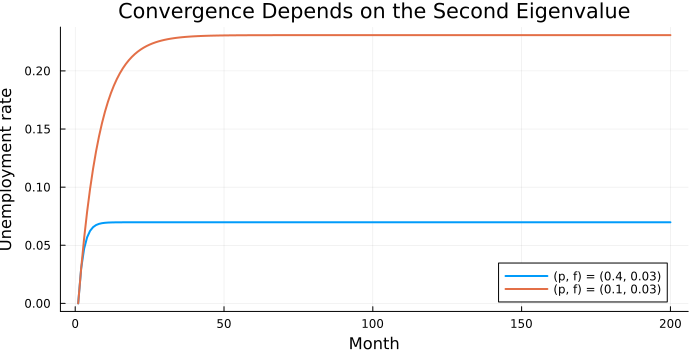

In [38]:
T4 = 200
u1 = simulate_u(0.4, 0.03, T4)          # baseline
u2 = simulate_u(0.1, 0.03, T4)          # slower job finding

plot(1:T4, u1, linewidth=2, label="(p, f) = (0.4, 0.03)",
     title="Convergence Depends on the Second Eigenvalue",
     xlabel="Month", ylabel="Unemployment rate", size=(700, 350))
plot!(1:T4, u2, linewidth=2, label="(p, f) = (0.1, 0.03)")

In [39]:
#p = 0.4, f = 0.03
A_pf = [1-0.03  0.4; 0.03  1-0.4]
println("Eigenvalues of A with (0.4, 0.03): $(eigvals(A_pf))")
#p = 0.1, f = 0.03
A_pf = [1-0.03  0.1; 0.03  1-0.1]
println("Eigenvalues of A with (0.1, 0.03): $(eigvals(A_pf))")

Eigenvalues of A with (0.4, 0.03): [0.57, 1.0]
Eigenvalues of A with (0.1, 0.03): [0.87, 1.0]


One can show that the eigenvalues of $A$ are $\{1,\; 1 - p - f\}$.
Deviations from the steady state decay geometrically at rate
$|1 - p - f|$ per period. For $(p,f) = (0.4, 0.03)$ the second
eigenvalue is $0.57$, so deviations shrink by about 43% per month; for
$(p,f) = (0.1, 0.03)$ it is $0.87$, so deviations shrink by only 13% per
month. The second calibration has the **larger** absolute second
eigenvalue and converges much more slowly.

**(c)** Eigenvalues of $P$ vs. $A$.

In [40]:
λ_P = eigvals(P)
println("Eigenvalues of P: $(round.(λ_P, digits=5))")
println("Eigenvalues of A: $(round.(eigvals(A), digits=5))")

Eigenvalues of P: [0.57, 1.0]
Eigenvalues of A: [0.57, 1.0]


The eigenvalues of $P$ and $A$ are identical: $\{1, 1 - p - f\}$. This
is because $A$ is the transpose of $P$ (after relabeling states), and
transposing a matrix or conjugating it by a permutation leaves the
eigenvalues unchanged.

# Conditional Expectations

## Problem 5: Expected Earnings

Employed workers earn $w = 1$; unemployed workers receive $b = 0.4$.

**(a)** Compute $P \bar x$ and interpret.

In [41]:
x̄ = [1.0, 0.4]     # (wage if employed, benefits if unemployed), matching P's ordering
Ex1 = P * x̄
println("One-step expected earnings:")
println("  E[x_{t+1} | employed today]   = $(round(Ex1[1], digits=4))")
println("  E[x_{t+1} | unemployed today] = $(round(Ex1[2], digits=4))")

One-step expected earnings:
  E[x_{t+1} | employed today]   = 0.982
  E[x_{t+1} | unemployed today] = 0.64


A worker who is employed today expects to earn
$(1-f) \cdot 1 + f \cdot 0.4 = 0.982$ next month — nearly the full wage,
because separations are rare. A worker who is unemployed today expects
$p \cdot 1 + (1-p) \cdot 0.4 = 0.64$ next month — a large expected jump
in earnings, because the job-finding rate is high.

**(b)** Plot $k$-step-ahead expected earnings for both starting states.

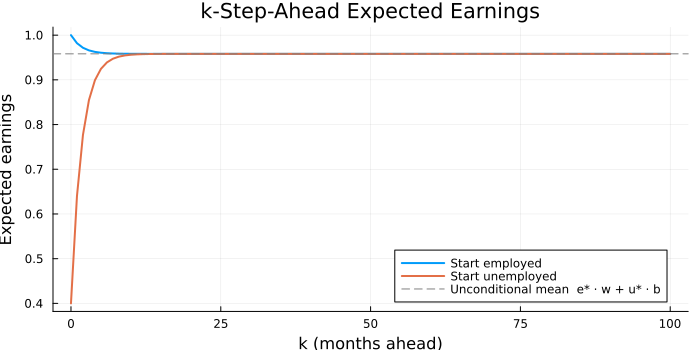

In [42]:
K = 100
Ex_emp = zeros(K + 1)
Ex_unemp = zeros(K + 1)
Pk = Matrix{Float64}(I, 2, 2)
for k in 0:K
    Ex = (P^k) * x̄
    Ex_emp[k+1]   = Ex[1]
    Ex_unemp[k+1] = Ex[2]
end

plot(0:K, Ex_emp, linewidth=2, label="Start employed",
     title="k-Step-Ahead Expected Earnings", xlabel="k (months ahead)",
     ylabel="Expected earnings", size=(700, 350))
plot!(0:K, Ex_unemp, linewidth=2, label="Start unemployed")
hline!([e_star * 1.0 + u_star * 0.4], linestyle=:dash, color=:gray,
       label="Unconditional mean  e* · w + u* · b")

Both curves converge to the same limit
$e^* \cdot w + u^* \cdot b \approx 0.958$. This is the unconditional
mean of earnings under the steady-state distribution. As $k$ grows, the
conditional distribution $P^k[i, \cdot]$ converges to the steady-state
distribution regardless of the starting state $i$, so the conditional
expectation converges to the unconditional expectation.

**(c)** Present discounted value of expected earnings.

In [43]:
β = 0.99

# Finite sum: V^T = Σ_{k=0}^T β^k P^k x̄
T_sum = 2000
V_T = zeros(2)
Pk = Matrix{Float64}(I, 2, 2)
for k in 0:T_sum
    V_T .+= β^k .* (Pk * x̄)
    Pk = Pk * P
end

# Closed form: V = (I - β P)^{-1} x̄
V_closed = (I - β * P) \ x̄

println("Finite sum with T = $T_sum:")
println("  V(employed)   = $(round(V_T[1], digits=4))")
println("  V(unemployed) = $(round(V_T[2], digits=4))")

println("\nClosed form V = (I - β P)^{-1} x̄:")
println("  V(employed)   = $(round(V_closed[1], digits=4))")
println("  V(unemployed) = $(round(V_closed[2], digits=4))")

println("\nDifference: $(round.(V_T .- V_closed, digits=6))")

Finite sum with T = 2000:
  V(employed)   = 95.91
  V(unemployed) = 94.5329

Closed form V = (I - β P)^{-1} x̄:
  V(employed)   = 95.91
  V(unemployed) = 94.5329

Difference: [-0.0, -0.0]


The finite sum matches the closed form to many decimals: as
$T \to \infty$ the remainder $\sum_{k > T} \beta^k P^k \bar x$ vanishes
geometrically because $|\beta| < 1$ and the eigenvalues of $P$ are
bounded by 1. If your curious as to how I got the closed 
for m solution. The closed-form expression $V = (I - \beta P)^{-1} \bar x$
is the solution to the Bellman equation $V = \bar x + \beta P V$.

# Estimating the Transition Matrix

## Problem 6: MLE from a Simulated Panel

**(a)** Estimate $\hat P$ from a $T = 200$ state sequence. We reuse
`simulateMarkov` from Problem 1 and write a short row-normalization
routine.

In [44]:
function estimateP(s, n_states)
    N = zeros(Int, n_states, n_states)
    for t in 2:length(s)
        N[s[t-1], s[t]] += 1
    end
    return N ./ sum(N, dims=2)
end

Random.seed!(2026)
s_small, _ = simulateMarkov(P, [1, 2], 200; s₁ = 1)
P̂_small = estimateP(s_small, 2)

2×2 Matrix{Float64}:
 0.973262  0.026738
 0.416667  0.583333

True $P$:

In [45]:
round.(P, digits=3)

2×2 Matrix{Float64}:
 0.97  0.03
 0.4   0.6

Estimated $\hat P$ from $T = 200$ months:

In [46]:
round.(P̂_small, digits=3)

2×2 Matrix{Float64}:
 0.973  0.027
 0.417  0.583

Maximum absolute error:

In [47]:
round(maximum(abs.(P̂_small .- P)), digits=3)

0.017

With only 200 months the estimate is in the right ballpark: the diagonal
entries are accurate, but the off-diagonal entries (especially
$\hat P_{1,2}$, the separation probability) can have large relative errors

**(b)** Error vs. sample size on a log-log scale.

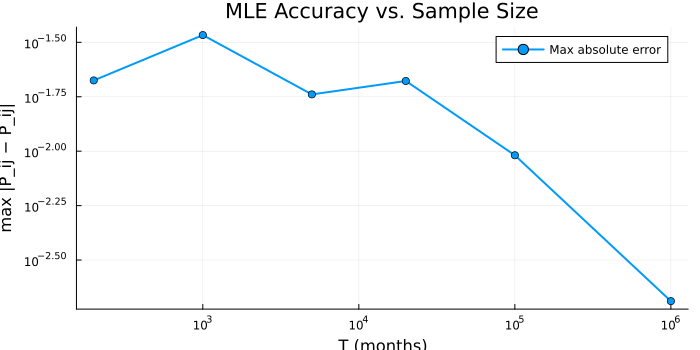

In [48]:
Ts = [200, 1_000, 5_000, 20_000, 100_000, 1_000_000]
errors = zeros(length(Ts))
for (i, Ti) in enumerate(Ts)
    s_i, _ = simulateMarkov(P, [1, 2], Ti; s₁ = 1)
    P̂_i = estimateP(s_i, 2)
    errors[i] = maximum(abs.(P̂_i .- P))
end

plot(Ts, errors, marker=:circle, linewidth=2, xscale=:log10, yscale=:log10,
     label="Max absolute error", title="MLE Accuracy vs. Sample Size",
     xlabel="T (months)", ylabel="max |P̂_ij − P_ij|", size=(700, 350))

**(c)** Why are the off-diagonal entries noisier, and how does this
connect to “rare events”?

The MLE $\hat P_{ij} = n_{ij} / n_{i\cdot}$ is a sample proportion. Its
standard error is approximately
$\sqrt{P_{ij}(1 - P_{ij}) / n_{i\cdot}}$. With $p = 0.4$ and $f = 0.03$,
the vast majority of the $T-1$ transitions happen from the employed
state, and of those, only a fraction $f = 0.03$ end in unemployment. So
the **count** $n_{1,2}$ is small, and a small count gives a large
relative standard error on $\hat P_{1,2}$. The diagonal entries, in
contrast, involve the bulk of the observations and are estimated
precisely.

This is exactly the “rare events” issue from the NBER application in
lecture. Recessions are rare: only about a dozen transitions from
expansion to recession in 77 years of monthly data. This means that the
expansion-to-recession probability is estimated from a handful of events
and is correspondingly uncertain. Predicting the onset of recessions is
hard precisely because the training sample contains very few of them.